In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/train.csv")




In [2]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

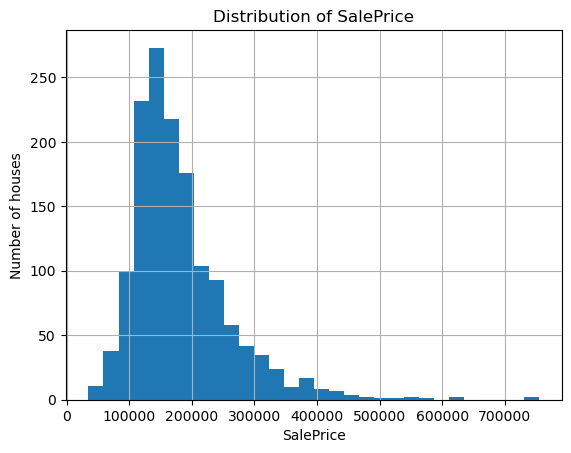

In [3]:
df["SalePrice"].hist(bins=30)
plt.xlabel("SalePrice")
plt.ylabel("Number of houses")
plt.title("Distribution of SalePrice")
plt.show()

### Distribution of SalePrice

The distribution of `SalePrice` is right-skewed.  
Most houses are concentrated at lower price values, while a small number of houses have very high prices.  
This means that the data is not normally distributed.

This observation is important because many statistical methods and regression models assume normally distributed data.  
Therefore, the distribution of `SalePrice` will need to be addressed in the next step.


In [4]:
import numpy as np

df["LogSalePrice"] = np.log(df["SalePrice"])

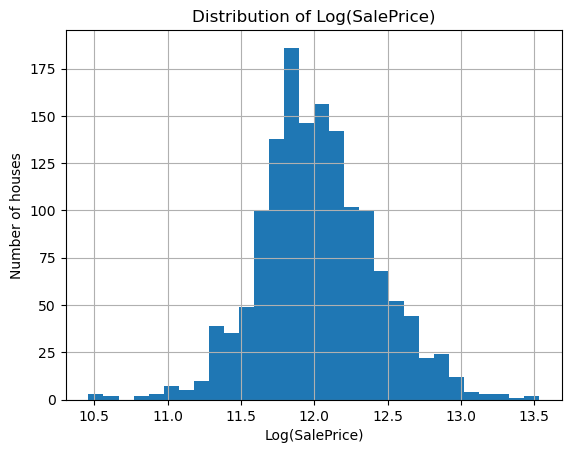

In [5]:
df["LogSalePrice"].hist(bins=30)
plt.xlabel("Log(SalePrice)")
plt.ylabel("Number of houses")
plt.title("Distribution of Log(SalePrice)")
plt.show()

### Distribution and Transformation of `SalePrice`

In this stage, the distribution of the target variable (`SalePrice`) is examined in more detail.  
The initial analysis shows that house prices are not normally distributed and are strongly right-skewed, mainly due to a small number of very expensive houses.

To reduce the impact of these extreme values, a logarithmic transformation is applied to `SalePrice`.  
A new variable, `LogSalePrice`, is created using the logarithm of the original prices.

After the transformation, the distribution becomes more balanced and closer to a bell-shaped form.  
While the data is still not perfectly normal, the influence of extreme high-price observations is reduced.

This step helps prepare the data for later stages of the project, including statistical inference and linear regression analysis.

### Comparing House Prices by Central Air Conditioning

The first comparison in this stage looks at whether houses with central air conditioning sell for more than houses without central air conditioning.

Central air conditioning is chosen because it is a simple and clear feature that divides houses into two groups:
- houses with central air
- houses without central air

House prices are compared using `LogSalePrice` to reduce the effect of extreme values.

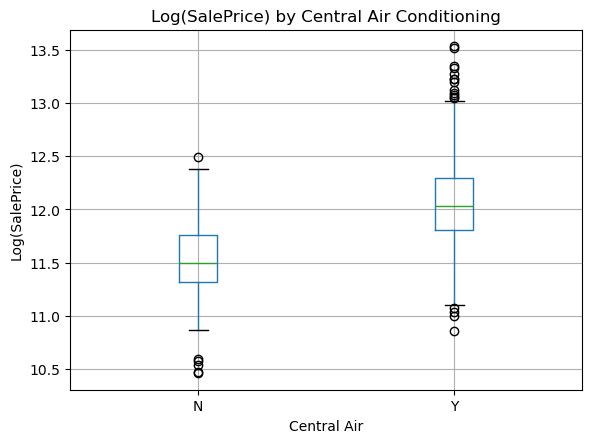

In [6]:
with_air = df[df["CentralAir"] == "Y"]["LogSalePrice"]
without_air = df[df["CentralAir"] == "N"]["LogSalePrice"]

df.boxplot(column="LogSalePrice", by="CentralAir")
plt.title("Log(SalePrice) by Central Air Conditioning")
plt.suptitle("")
plt.xlabel("Central Air")
plt.ylabel("Log(SalePrice)")
plt.show()

### Interpretation

The boxplot shows a clear difference between houses with and without central air conditioning.  
Houses with central air tend to have higher log-transformed sale prices compared to houses without central air.

There is noticeable variability within each group, which suggests that central air conditioning is not the only factor influencing house prices.  
Overall, this comparison provides initial evidence that central air conditioning is associated with higher house prices.